In [5]:
# Import all libraries we need for data analysis and visualization
import pandas as pd        # pandas: for loading, cleaning, and analyzing data
import numpy as np         # numpy: for numerical calculations
import matplotlib.pyplot as plt  # matplotlib: for creating charts
import seaborn as sns      # seaborn: for beautiful statistical visualizations
import warnings
warnings.filterwarnings('ignore')  # suppress minor warnings for clean output

# Set a consistent visual style for all charts
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)  # default chart size: 12 wide, 6 tall

print("Libraries loaded!")

Libraries loaded!


In [8]:
# CDC has free public health data for every county in the US — no login needed
# pulling it straight from their API so i dont have to download anything
url = 'https://data.cdc.gov/api/views/swc5-untb/rows.csv?accessType=DOWNLOAD'

print('Downloading CDC data... this may take 30-60 seconds...')
df_raw = pd.read_csv(url)  # read the CSV directly from the URL into a dataframe

# Filter to Florida only — we only want FL counties for this analysis
df = df_raw[df_raw['StateAbbr'] == 'FL'].copy()

print(f'Total rows downloaded: {df_raw.shape[0]:,}')  # full US dataset size
print(f'Florida rows: {df.shape[0]:,}')               # FL subset size
print('Done!')

Total rows downloaded: 229,298
Florida rows: 4,422
Done!


In [6]:
# Define the 6 chronic conditions we want to analyze
# These are the MeasureId codes used by CDC PLACES
measures_of_interest = {
    'DIABETES': 'Diabetes Prevalence (%)',
    'HIGHCHOL': 'High Cholesterol (%)',
    'BPHIGH':   'High Blood Pressure (%)',
    'OBESITY':  'Obesity (%)',
    'CASTHMA':  'Asthma (%)',
    'CHD':      'Coronary Heart Disease (%)'
}

# Keep only rows matching our 6 conditions
df_filtered = df[df['MeasureId'].isin(measures_of_interest.keys())].copy()

# Add a human-readable label column using our dictionary above
df_filtered['Measure_Label'] = df_filtered['MeasureId'].map(measures_of_interest)

# Keep only the columns we need and drop any rows with missing values
df_filtered = df_filtered[['LocationName', 'MeasureId', 'Measure_Label', 'Data_Value']].dropna()

# Rename columns to be clean and readable
df_filtered.columns = ['County', 'MeasureId', 'Measure', 'Prevalence']

print(f'Filtered rows: {df_filtered.shape[0]}')
print(f'Counties found: {df_filtered["County"].nunique()}')  # should be 67 FL counties
print(f'Measures found: {df_filtered["Measure"].nunique()}') # should be 6
df_filtered.head(10)  # preview the first 10 rows

Filtered rows: 804
Counties found: 67
Measures found: 6


,County,MeasureId,Measure,Prevalence
13,Brevard,DIABETES,Diabetes Prevalence (%),13.1
14,Citrus,DIABETES,Diabetes Prevalence (%),15.8
18113,Hardee,OBESITY,Obesity (%),40.6
18156,Seminole,OBESITY,Obesity (%),29.3
18169,Broward,BPHIGH,High Blood Pressure (%),32.1
18258,Washington,OBESITY,Obesity (%),39.8
18280,Monroe,CASTHMA,Asthma (%),8.9
18282,Santa Rosa,OBESITY,Obesity (%),31.7
18308,Duval,CASTHMA,Asthma (%),10.3
18340,Calhoun,CASTHMA,Asthma (%),10.6


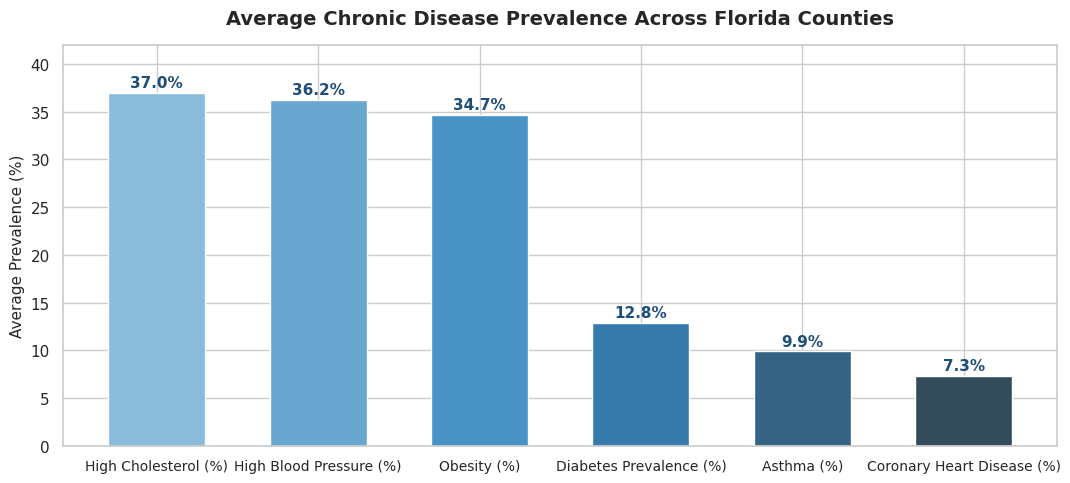

Chart 1 saved!


In [9]:
# first chart — want to see which conditions are most common across florida
avg_by_measure = df_filtered.groupby('Measure')['Prevalence'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(11, 5))
colors = sns.color_palette('Blues_d', len(avg_by_measure))
bars = ax.bar(avg_by_measure.index, avg_by_measure.values, color=colors, edgecolor='white', width=0.6)

# adding the percentage labels on top of each bar so its easy to read
for bar, val in zip(bars, avg_by_measure.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold', color='#1F4E79')

ax.set_title('Average Chronic Disease Prevalence Across Florida Counties', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Average Prevalence (%)', fontsize=11)
ax.set_ylim(0, avg_by_measure.max() + 5)
ax.tick_params(axis='x', labelsize=10)
plt.tight_layout()

# saving it so i can post it on linkedin later
plt.savefig('fig1_statewide_prevalence.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 1 saved!')

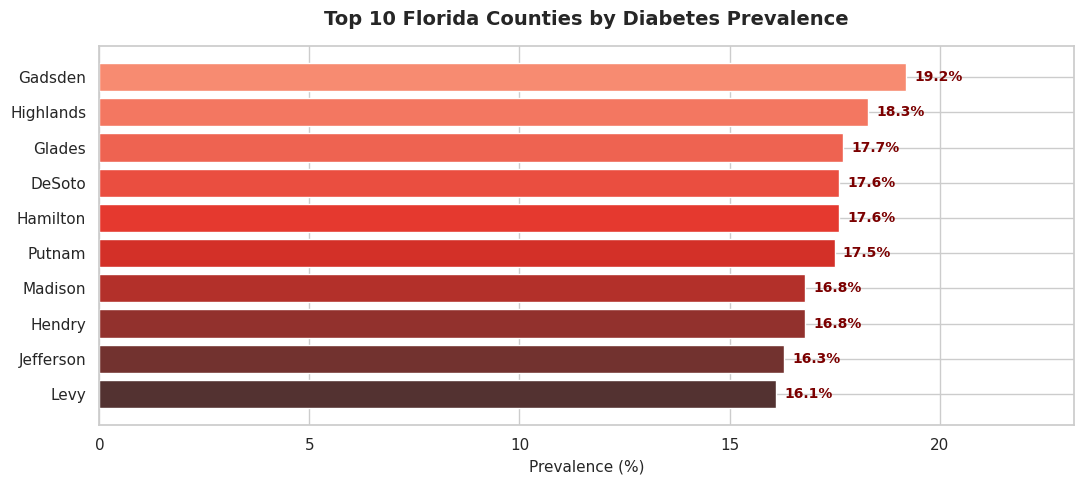

Chart 2 saved!


In [10]:
# diabetes is one of the biggest burdens on the healthcare system
# wanted to see which florida counties are hit the hardest
diabetes = df_filtered[df_filtered['MeasureId'] == 'DIABETES'].sort_values('Prevalence', ascending=False)
top10_diabetes = diabetes.head(10)

fig, ax = plt.subplots(figsize=(11, 5))
colors = sns.color_palette('Reds_d', 10)

# horizontal bar chart works better here since county names are long
bars = ax.barh(top10_diabetes['County'][::-1], top10_diabetes['Prevalence'][::-1],
               color=colors[::-1], edgecolor='white')

# adding percentage labels at the end of each bar
for bar, val in zip(bars, top10_diabetes['Prevalence'][::-1]):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10, fontweight='bold', color='#7B0000')

ax.set_title('Top 10 Florida Counties by Diabetes Prevalence', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Prevalence (%)', fontsize=11)
ax.set_xlim(0, top10_diabetes['Prevalence'].max() + 4)
plt.tight_layout()

# this one is going on linkedin for sure
plt.savefig('fig2_top10_diabetes.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 2 saved!')

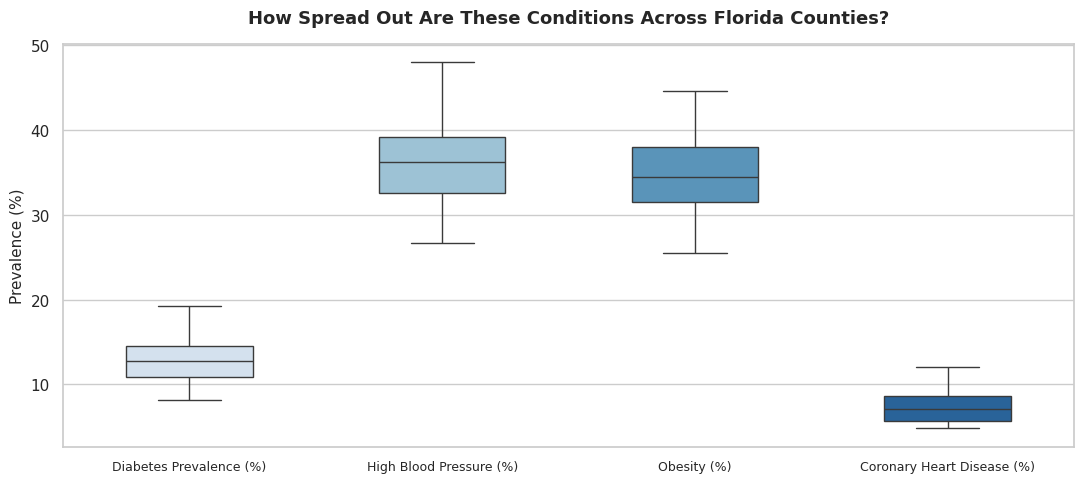

Chart 3 saved!


In [13]:
# box plots show the spread across all 67 counties not just the average
# good for spotting outlier counties that are way above or below the norm
focus_measures = ['Diabetes Prevalence (%)', 'High Blood Pressure (%)', 'Obesity (%)', 'Coronary Heart Disease (%)']
df_box = df_filtered[df_filtered['Measure'].isin(focus_measures)]

fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(data=df_box, x='Measure', y='Prevalence', palette='Blues',
            order=focus_measures, ax=ax, width=0.5)

ax.set_title('How Spread Out Are These Conditions Across Florida Counties?', fontsize=13, fontweight='bold', pad=15)
ax.set_ylabel('Prevalence (%)', fontsize=11)
ax.set_xlabel('')
ax.tick_params(axis='x', labelsize=9)
plt.tight_layout()

plt.savefig('fig3_distribution_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 3 saved!')

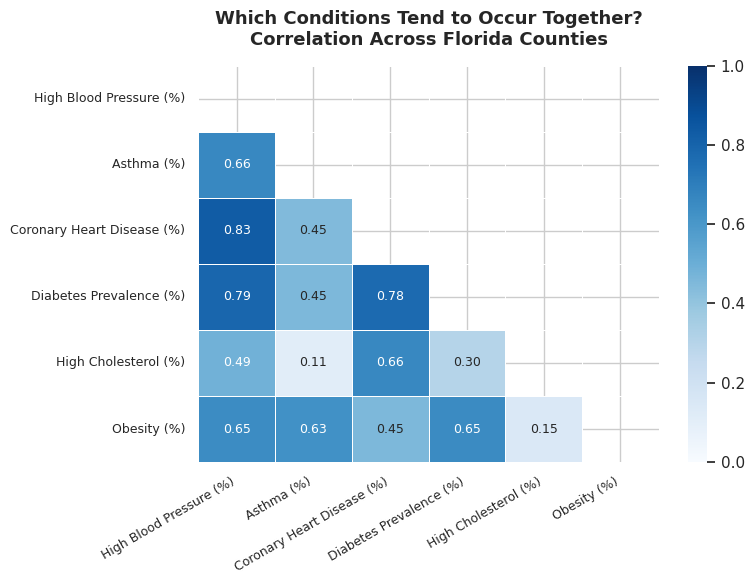

Chart 4 saved!


In [14]:
# wanted to see which conditions tend to show up together across counties
# if two conditions are correlated it means counties with high diabetes
# also tend to have high blood pressure for example
pivot = df_filtered.pivot_table(index='County', columns='MeasureId', values='Prevalence')
pivot.columns = [measures_of_interest.get(c, c) for c in pivot.columns]
corr = pivot.corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))  # only show the bottom half — cleaner
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='Blues',
            linewidths=0.5, ax=ax, vmin=0, vmax=1,
            annot_kws={'size': 9})

ax.set_title('Which Conditions Tend to Occur Together?\nCorrelation Across Florida Counties', fontsize=13, fontweight='bold', pad=15)
plt.xticks(rotation=30, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()

plt.savefig('fig4_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 4 saved!')

In [16]:
# pulling out the key numbers to write up my findings
diabetes = df_filtered[df_filtered['MeasureId'] == 'DIABETES'].sort_values('Prevalence', ascending=False)
bp = df_filtered[df_filtered['MeasureId'] == 'BPHIGH'].sort_values('Prevalence', ascending=False)
obesity = df_filtered[df_filtered['MeasureId'] == 'OBESITY'].sort_values('Prevalence', ascending=False)

highest_diabetes_county = diabetes.iloc[0]['County']
highest_diabetes_val = diabetes.iloc[0]['Prevalence']
avg_diabetes = round(diabetes['Prevalence'].mean(), 1)

highest_bp_county = bp.iloc[0]['County']
highest_bp_val = bp.iloc[0]['Prevalence']

highest_obesity_county = obesity.iloc[0]['County']
highest_obesity_val = obesity.iloc[0]['Prevalence']

print('=' * 60)
print('FLORIDA CHRONIC DISEASE ANALYSIS — KEY FINDINGS')
print('=' * 60)
print(f'''
DIABETES
- Statewide average: {avg_diabetes}%
- Highest county: {highest_diabetes_county} at {highest_diabetes_val}%
- Counties above average are priority targets for diabetes
  management programs and EHR-driven outreach

HIGH BLOOD PRESSURE
- Highest county: {highest_bp_county} at {highest_bp_val}%
- Strong correlation with diabetes suggests these patients
  need coordinated care team management

OBESITY
- Highest county: {highest_obesity_county} at {highest_obesity_val}%
- Co-occurs heavily with diabetes and hypertension

CLINICAL INFORMATICS TAKEAWAY
- Population health tools built on data like this help
  healthcare systems like Epic flag high-risk patients
  and allocate resources to the right counties
''')
print('=' * 60)

FLORIDA CHRONIC DISEASE ANALYSIS — KEY FINDINGS

DIABETES
- Statewide average: 12.8%
- Highest county: Gadsden at 19.2%
- Counties above average are priority targets for diabetes
  management programs and EHR-driven outreach

HIGH BLOOD PRESSURE
- Highest county: Sumter at 48.0%
- Strong correlation with diabetes suggests these patients
  need coordinated care team management

OBESITY
- Highest county: Gadsden at 44.6%
- Co-occurs heavily with diabetes and hypertension

CLINICAL INFORMATICS TAKEAWAY
- Population health tools built on data like this help
  healthcare systems like Epic flag high-risk patients
  and allocate resources to the right counties

